# <span style="color: #57A0D2"> Titanic</span> <span style="color: #4D516D"> Dataset </span>

### </span> <span style="color: #4D516D">1. Preliminary Exploration</span>
- Missing Age Values: We can fill the missing age values by replacing missing values with the median age of passangers grouped by sex and passenger class. This is more accurate than using the overall median as first-class female passengers would likely have a different age pattern than third class male passengers
- Converting Gender: A decision tree requires numerical inputs and the "sex" column is categorical, so we can convert this column by making males -> 1 and females -> 0 to keep gender binary 

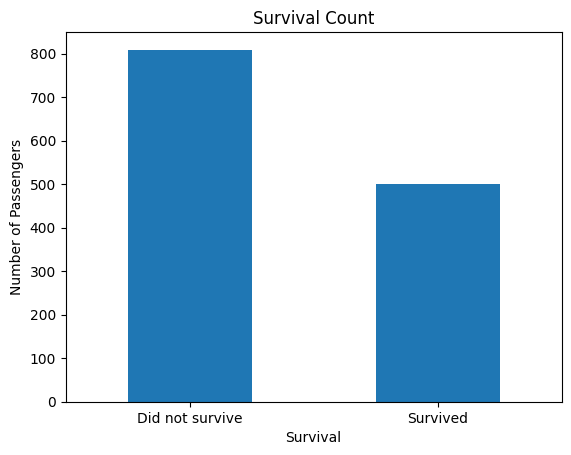

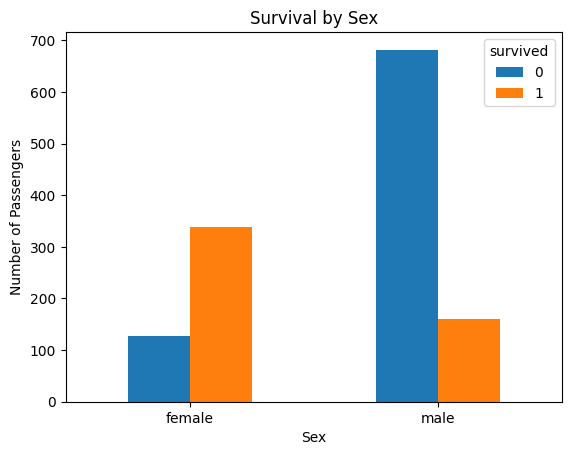

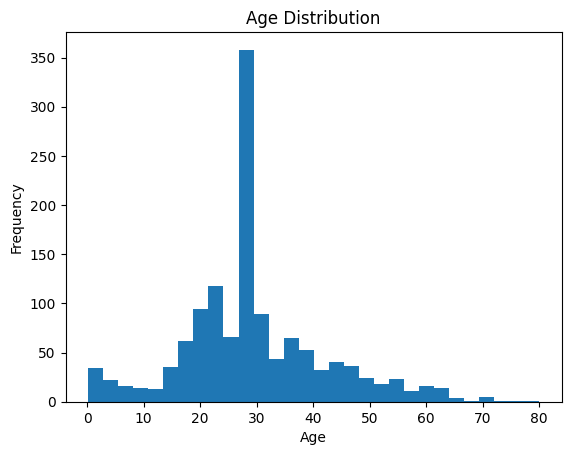

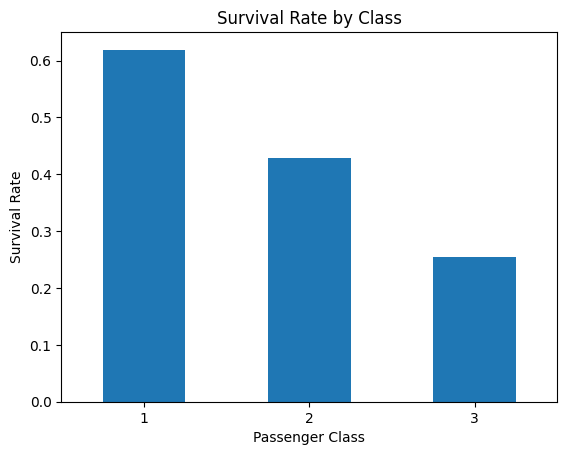

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("Titanic Dataset.csv")

# Graph 1: Survival Count
plt.figure()
df["survived"].value_counts().sort_index().plot(kind="bar")
plt.xticks([0, 1], ["Did not survive", "Survived"], rotation=0)
plt.xlabel("Survival")
plt.ylabel("Number of Passengers")
plt.title("Survival Count")
plt.show()

# Graph 2: Survival by Sex
pd.crosstab(df["sex"], df["survived"]).plot(kind="bar")
plt.xlabel("Sex")
plt.ylabel("Number of Passengers")
plt.title("Survival by Sex")
plt.xticks(rotation=0)
plt.show()

# Graph 3: Age Distribution
plt.figure()
df['age'] = df['age'].fillna(df['age'].median())
df["age"].plot(kind="hist", bins=30)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")
plt.show()

# Graph 4: Survival Rate by Class
df.groupby("pclass")["survived"].mean().plot(kind="bar")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.title("Survival Rate by Class")
plt.xticks(rotation=0)
plt.show()

### <span style="color: #4D516D">2. Splitting Data</span>
The random_state = 42 ensures that the data is split the same way every time the code is run. Since the split is random, different runs would normally produce different training and testing sets, which could lead to different model results. Setting a fixed random_state makes the results reproducible and consistent, allowing for fair comparisons and easier debugging.

In [4]:
from sklearn.model_selection import train_test_split

X = df[["pclass", "sex", "age", "fare"]]
y = df["survived"]

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size = 0.2,random_state = 42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (1047, 4)
Testing set size: (262, 4)


### <span style="color: #4D516D">3. Training the Tree</span>
Becuase the training accuracy is 96.6% but the test accuracy is 75.6%, it is likely the model has overfit the training data. It learned the training set too exactly and now cannot generalize well to new data.

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

df = pd.read_csv("Titanic Dataset.csv")

# Clean and convert sex
df["sex"] = df["sex"].str.strip().str.lower()
df["sex"] = df["sex"].map({"male": 1, "female": 0})

# Fill missing values
df["age"] = df["age"].fillna(df.groupby(["sex", "pclass"])["age"].transform("median"))
df["age"] = df["age"].fillna(df["age"].median())
df["fare"] = df["fare"].fillna(df["fare"].median())

# Choose only numeric feature columns
X = df[["pclass", "sex", "age", "sibsp", "parch", "fare"]]
y = df["survived"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 0.9694364851957975
Testing Accuracy: 0.7404580152671756


### <span style="color: #4D516D">4. Plot Tree</span>
The model chose "sex" as the first split for the dataset. This makes logical sense because women were much more likely to survive than men because of the “women and children first” evacuation pattern.

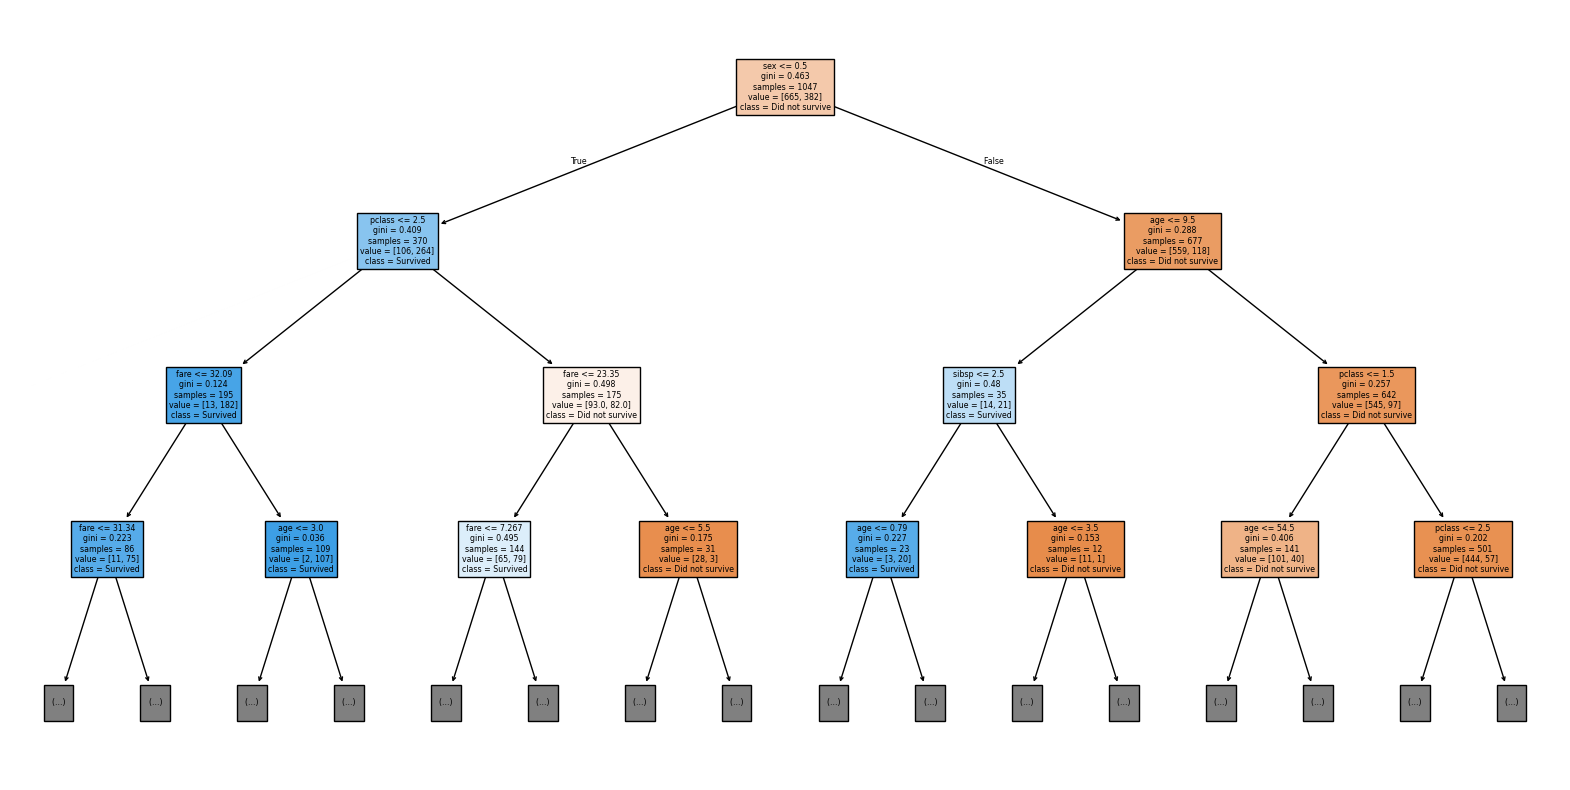

In [6]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Did not survive", "Survived"],
    filled=True,
    max_depth=3   # shows the first 3 levels: root, children, grandchildren
)
plt.show()

### <span style="color: #4D516D">5. Pruning for Health</span>
Limiting the tree’s depth often improves performance on the test set because it reduces overfitting. A fully grown tree becomes very complex and starts memorizing the training data, including noise and small irregularities. This leads to very high training accuracy but poorer performance on new, unseen data. By setting max_depth=3, the tree is forced to remain simpler and only capture the most important patterns in the data. This makes the model more generalizable, so it performs better on the test set even if it is slightly less accurate on the training set.

In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

model_pruned = DecisionTreeClassifier(max_depth=3, random_state=42)
model_pruned.fit(X_train, y_train)

y_test_pred_pruned = model_pruned.predict(X_test)

test_accuracy_pruned = accuracy_score(y_test, y_test_pred_pruned)

print("Original Test Accuracy:", test_accuracy)
print("Pruned Tree Test Accuracy:", test_accuracy_pruned)

Original Test Accuracy: 0.7404580152671756
Pruned Tree Test Accuracy: 0.7786259541984732


### <span style="color: #4D516D">6. Growing the Forest</span>
A single decision tree makes a prediction by following one fixed set of rules from top to bottom, meaning its decision is based on one structure and can be sensitive to noise in the data. In contrast, a random forest builds many different trees using slightly varied data and features, and each tree makes its own prediction. The final output is determined by combining these predictions, typically through majority voting, which makes the model more stable and less likely to overfit.

In [8]:
from sklearn.ensemble import RandomForestClassifier

# Initialize forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train
rf_model.fit(X_train, y_train)

# Predict
rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)

from sklearn.metrics import accuracy_score
print("RF Training Accuracy:", accuracy_score(y_train, rf_train_pred))
print("RF Testing Accuracy:", accuracy_score(y_test, rf_test_pred))

RF Training Accuracy: 0.9694364851957975
RF Testing Accuracy: 0.7824427480916031


### <span style="color: #4D516D">7. Confusion Matrix</span>
The model predicted 497 people who would survive that actually didn't and 38 people were predicted dead that actually survived

In [10]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, rf_test_pred)

print("Confusion Matrix:")
print(cm)

false_positives = cm[0, 1]
false_negatives = cm[1, 0]

print("False Positives (predicted survived but actually died):", false_positives)
print("False Negatives (predicted died but actually survived):", false_negatives)

Confusion Matrix:
[[127  17]
 [ 40  78]]
False Positives (predicted survived but actually died): 17
False Negatives (predicted died but actually survived): 40


### <span style="color: #4D516D">8. Precision and Recall</span>
The higher precision value (roughly 0.82) tells us how accurate our positive prediction values are, essentially, for all of the people who the model predicted survived, how many actually did

The lower recall value (roughly 0.66) measures of all the people who actually survived, how many did the model successfully identify. This says that the model is not very good at catching survivors, but somewhat accurate at predicting survival. 

In [13]:
from sklearn.metrics import precision_score, recall_score

rf_precision = precision_score(y_test, rf_test_pred)
rf_recall = recall_score(y_test, rf_test_pred)

print("Precision:", rf_precision)
print("Recall:", rf_recall)

Precision: 0.8210526315789474
Recall: 0.6610169491525424


### <span style="color: #4D516D">9. ROC Curve</span>
AUC provides a single number (between 0 and 1) that summarizes how well a model can distinguish between classes.
Our high AUC iof 0.83 ndicates that the model is excellent at predicting positives as positives and negatives as negatives, essentially saying our model is really effective

AUC: 0.8275364877589455


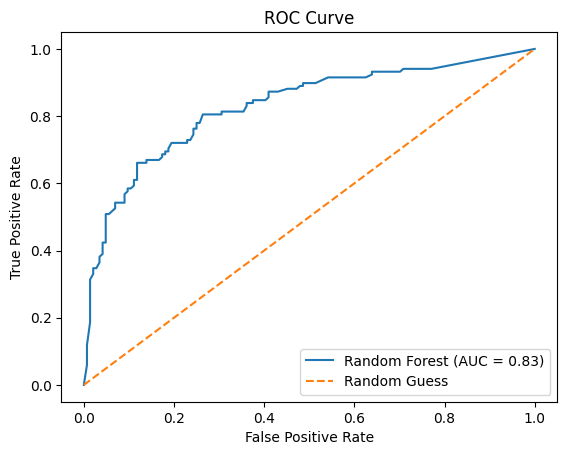

In [14]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probability of the positive class (survived = 1)
y_probs = rf_model.predict_proba(X_test)[:, 1]

# ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# AUC score
auc_score = roc_auc_score(y_test, y_probs)
print("AUC:", auc_score)

# Plot ROC curve
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### <span style="color: #4D516D">10. Feature Improtance</span>

  Feature  Importance
5    fare    0.314972
1     sex    0.264002
2     age    0.251271
0  pclass    0.078359
3   sibsp    0.049287
4   parch    0.042109


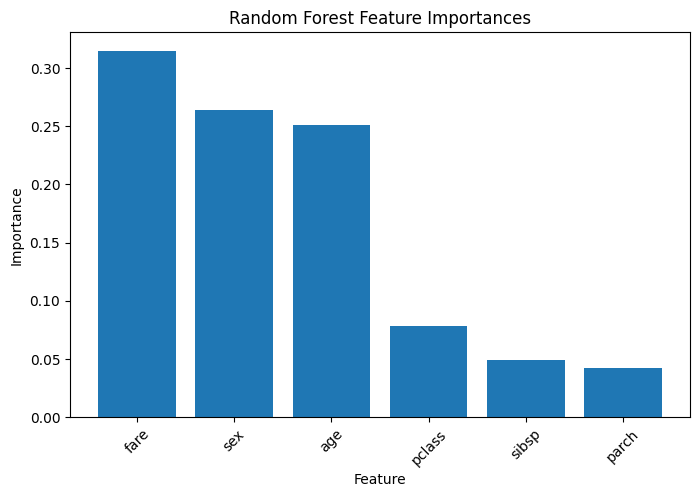

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_
feature_names = X_train.columns

feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

print(feat_imp)

plt.figure(figsize=(8,5))
plt.bar(feat_imp["Feature"], feat_imp["Importance"])
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importances")
plt.xticks(rotation=45)
plt.show()